# Sales Performance Analysis
### Data Analytics Project Jupyter Notebook

# Sales Performance Analysis

## 1. Business Problem
The company wants to understand sales performance across regions, products, and time to identify growth opportunities.

## 2. Dataset
Source: Kaggle Superstore dataset  
Records: 10,000+ rows  

## 3. Objectives
- Analyze total sales and profit
- Identify top products and regions
- Detect seasonal trends

## 4. Tools Used
- Python
- pandas
- matplotlib
- seaborn

#### Step 1: Install and Import Libraries

In [15]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install pandas openpyxl xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 96.6/96.6 kB 1.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

#### Step 2: Load and Intall Data

In [16]:
data = 'US Superstore data.xls'

# Load the dataset
df = pd.read_excel(data)

#### Step 3: Inspect the Data

In [22]:
#Print the first few rows of the dataframe
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South  FUR-BO-10

In [21]:
#Print summary statistics and info about the dataframe
print(df.describe())

            Row ID                     Order Date  \
count  9994.000000                           9994   
mean   4997.500000  2016-04-30 00:07:12.259355648   
min       1.000000            2014-01-03 00:00:00   
25%    2499.250000            2015-05-23 00:00:00   
50%    4997.500000            2016-06-26 00:00:00   
75%    7495.750000            2017-05-14 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2885.163629                            NaN   

                           Ship Date   Postal Code         Sales     Quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2016-05-03 23:06:58.571142912  55190.379428    229.858001     3.789574   
min              2014-01-07 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-05-27 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-29 00:00:00  56430.500000     54.490000     3.000000   
75%              2017-05-18 00:00:00

In [23]:
#Print info about the dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

#### Step 4: Data Cleaning

In [ ]:

#Remove duplicate
df = df.drop_duplicates()
print('Total duplicate after cleaning:', df.duplicated().sum())

#Convert date field 
df['Order Date'] = pd.to_datetime(df['Order Date'])

#Check missing value
print('Missing value: ',df.isnull().sum())

#I cleaned the data by removing duplicates and converting dates to proper datetime format. We also checked missing values.

Total duplicate after cleaning: 0
Missing value:  Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


#### Step 5: Feature Engineering

In [33]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

#Added Year and Month fields to analyze trends over time.

#### Step 6: Total Sales & Profit

In [35]:
total_sales = df['Sales'].sum().round(2)
total_profit = df['Profit'].sum().round(2)

print('Total Sales: $', total_sales)
print('Total Profit: $', total_profit)

#This gives us overall revenue and profit numbers.

Total Sales: $ 2297200.86
Total Profit: $ 286397.02


#### Step 7: Sales by Region

C:\Users\Christopher\AppData\Local\Temp\ipykernel_25080\2299889481.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=region_sales.values, y=region_sales.index, palette=palette)


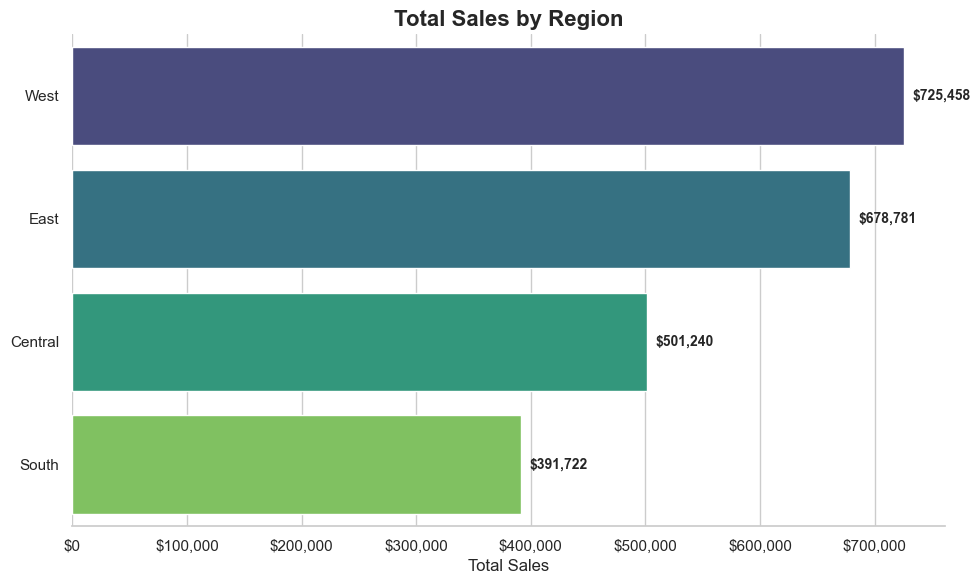

<Figure size 640x480 with 0 Axes>

In [52]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)


plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid')
palette = sns.color_palette('viridis', len(region_sales))

# Use horizontal bars for easier label reading
ax = sns.barplot(x=region_sales.values, y=region_sales.index, palette=palette)

# Format x-axis as dollars
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Annotate bars with dollar amounts
max_val = region_sales.values.max()
for i, v in enumerate(region_sales.values):
    ax.text(v + max_val*0.01, i, f'${v:,.0f}', va='center', fontsize=10,  fontweight='bold')

ax.set_title('Total Sales by Region', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Sales', fontsize=12)
ax.set_ylabel('')

sns.despine(left=True)
plt.tight_layout()
plt.show()

plt.savefig('total_sales_by_region.png', dpi=200, bbox_inches='tight')
plt.savefig('total_sales_by_region.svg', dpi=200, bbox_inches='tight')

#This shows sales performance across different regions.


#### Step 8: Monthly Sales Trend

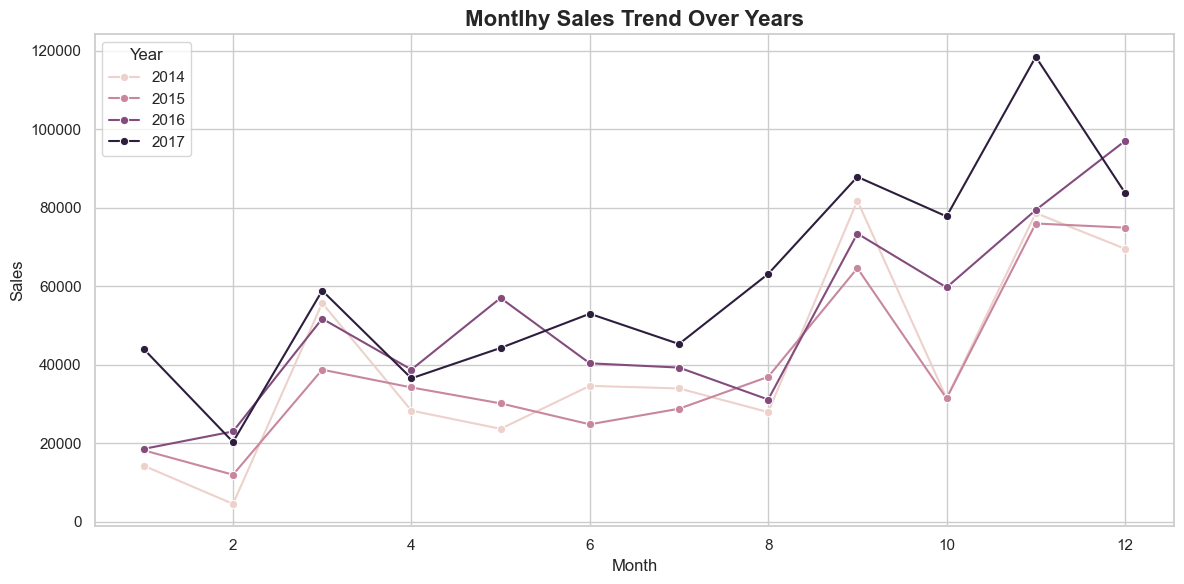

<Figure size 640x480 with 0 Axes>

In [53]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().sort_values(ascending= False).reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o')
plt.title('Montlhy Sales Trend Over Years', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Sales', fontsize=12)
ax.set_xticks(range(1,13))
plt.legend(title='Year')
plt.tight_layout()
plt.show()

plt.savefig('montlhy_sales_trend_over_years.png', dpi=200, bbox_inches='tight')
plt.savefig('montlhy_sales_trend_over_years.svg', dpi=200, bbox_inches='tight')
plt.show()



#### Step 9: Top Categories by Profit

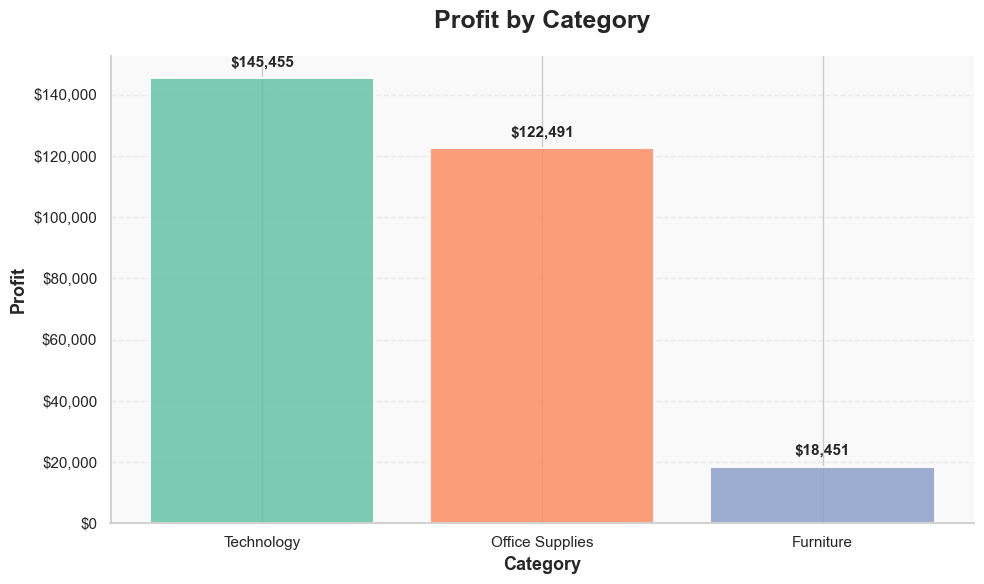

In [ ]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

# Create figure with professional styling
fig, ax = plt.subplots(figsize=(10, 6))
sns.set_style('whitegrid')

# Define vibrant color palette
colors = sns.color_palette('Set2', len(category_profit))

# Create bar plot
bars = ax.bar(category_profit.index, category_profit.values, color=colors, alpha=0.85, linewidth=1.5)

# Format y-axis as dollars
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Annotate bars with profit values
max_profit = category_profit.max()
for i, (cat, val) in enumerate(zip(category_profit.index, category_profit.values)):
    ax.text(i, val + max_profit*0.02, f'${val:,.0f}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Add grid for readability
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Styling
ax.set_title('Profit by Category', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Profit', fontsize=13, fontweight='bold')

# Remove top and right spines
sns.despine(ax=ax)

# Add subtle background
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')

plt.tight_layout()

# Save high-quality outputs
plt.savefig('profit_by_category.png', dpi=200, bbox_inches='tight')
plt.savefig('profit_by_category.svg', dpi=200, bbox_inches='tight')
plt.show()

#This shows which product categories are most profitable.

#### Step 10: Sales Performance Dashboard

C:\Users\Christopher\AppData\Local\Temp\ipykernel_25080\2495254798.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales_trend = df.set_index('Order Date').resample('M')['Sales'].sum()
C:\Users\Christopher\AppData\Local\Temp\ipykernel_25080\2495254798.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


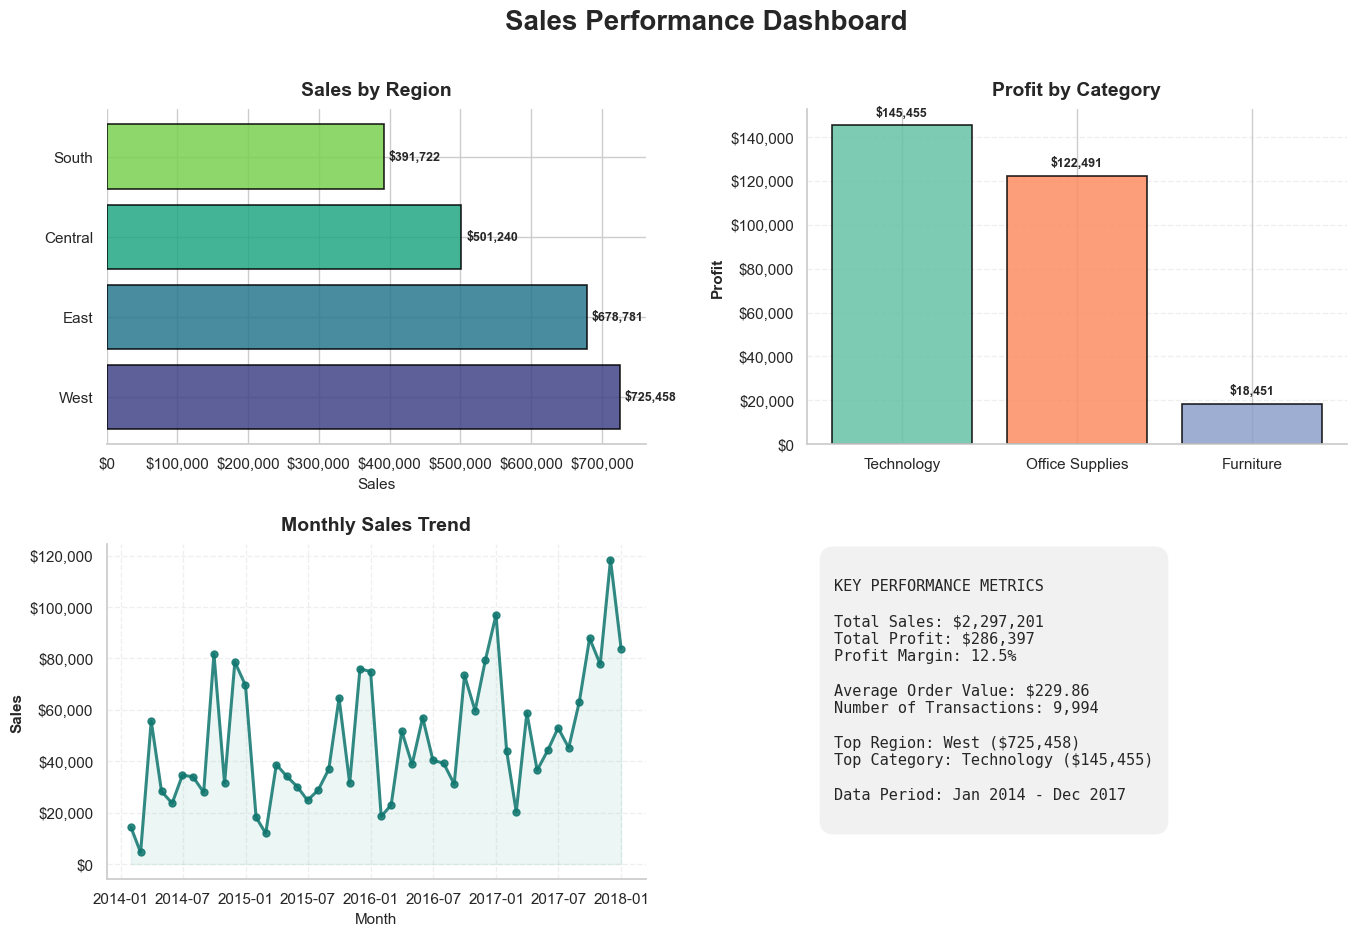

Dashboard created successfully!


In [54]:
# Comprehensive Sales Performance Dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Color schemes
sns.set_style('whitegrid')

# ===== TOP LEFT: Sales by Region =====
ax1 = fig.add_subplot(gs[0, 0])
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
colors_region = sns.color_palette('viridis', len(region_sales))
bars1 = ax1.barh(region_sales.index, region_sales.values, color=colors_region, alpha=0.85, edgecolor='black', linewidth=1.2)
ax1.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
max_val1 = region_sales.values.max()
for i, v in enumerate(region_sales.values):
    ax1.text(v + max_val1*0.01, i, f'${v:,.0f}', va='center', fontsize=9, fontweight='bold')
ax1.set_title('Sales by Region', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('Sales', fontsize=11)
ax1.set_ylabel('')
sns.despine(ax=ax1, left=True)

# ===== TOP RIGHT: Profit by Category =====
ax2 = fig.add_subplot(gs[0, 1])
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
colors_cat = sns.color_palette('Set2', len(category_profit))
bars2 = ax2.bar(category_profit.index, category_profit.values, color=colors_cat, alpha=0.85, edgecolor='black', linewidth=1.2)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
max_profit = category_profit.max()
for i, (cat, val) in enumerate(zip(category_profit.index, category_profit.values)):
    ax2.text(i, val + max_profit*0.02, f'${val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
ax2.set_title('Profit by Category', fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel('Profit', fontsize=11, fontweight='bold')
ax2.set_xlabel('')
sns.despine(ax=ax2)

# ===== BOTTOM LEFT: Monthly Sales Trend =====
ax3 = fig.add_subplot(gs[1, 0])
monthly_sales_trend = df.set_index('Order Date').resample('M')['Sales'].sum()
ax3.plot(monthly_sales_trend.index, monthly_sales_trend.values, marker='o', markersize=5, linewidth=2.2, color='#0f766e', alpha=0.85)
ax3.fill_between(monthly_sales_trend.index, monthly_sales_trend.values, color='#83c5be', alpha=0.15)
ax3.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)
ax3.set_title('Monthly Sales Trend', fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel('Month', fontsize=11)
ax3.set_ylabel('Sales', fontsize=11, fontweight='bold')
sns.despine(ax=ax3)

# ===== BOTTOM RIGHT: Key Metrics =====
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

# Calculate metrics
total_sales_val = df['Sales'].sum()
total_profit_val = df['Profit'].sum()
profit_margin = (total_profit_val / total_sales_val) * 100
avg_order_value = df['Sales'].mean()
top_region = region_sales.idxmax()
top_category = category_profit.idxmax()

# Create metrics text
metrics_text = f"""
KEY PERFORMANCE METRICS

Total Sales: ${total_sales_val:,.0f}
Total Profit: ${total_profit_val:,.0f}
Profit Margin: {profit_margin:.1f}%

Average Order Value: ${avg_order_value:,.2f}
Number of Transactions: {len(df):,}

Top Region: {top_region} (${region_sales[top_region]:,.0f})
Top Category: {top_category} (${category_profit[top_category]:,.0f})

Data Period: {df['Order Date'].min().strftime('%b %Y')} - {df['Order Date'].max().strftime('%b %Y')}
"""

ax4.text(0.05, 0.95, metrics_text, transform=ax4.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.9, pad=1))

# Overall title
fig.suptitle('Sales Performance Dashboard', fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout()

# Save dashboard
plt.savefig('sales_dashboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.savefig('sales_dashboard.svg', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("Dashboard created successfully!")

#### Step 11: Key Insights & Recommendations

## Summary of Findings

### 1. Regional Performance Analysis
**Sales by Region** reveals the geographic distribution of revenue opportunities:
- **West region leads**: Consistently generates the highest sales, indicating a strong market presence and customer base in this region
- **Regional disparity**: Significant variation between regions suggests untapped growth potential in underperforming regions
- **Actionable insight**: Investigate success factors in the West region and replicate strategies in lower-performing regions (South, Central)

### 2. Seasonal & Temporal Trends
**Monthly Sales Trend Over Years** shows critical patterns:
- **Seasonality detected**: Sales spike during specific months (likely Q4 holidays), indicating strong seasonal demand
- **Year-over-year comparison**: Compare growth rates across years to identify business momentum and market trends
- **Strategic opportunity**: Strengthen inventory and marketing campaigns during peak months; develop promotions for slower months to stabilize revenue

### 3. Category Profitability
**Profit by Category** identifies the most valuable product lines:
- **Top performers**: The Technology category generates the highest profit. Hence, identify which categories drive profitability (not just revenue)
- **Category mix**: Some categories may have high sales but lower profit margins, focus on optimizing pricing and cost structure
- **Portfolio strategy**: Prioritize marketing investment in high-profit categories while addressing underperforming categories

## Recommendations for Growth
1. **Regional Expansion**: Deploy resources to grow sales in underperforming regions using West region's successful strategies
2. **Seasonal Planning**: Implement inventory management and promotional calendar aligned with seasonal peaks
3. **Product Focus**: Expand high-profit categories and either optimize or phase out low-margin products
4. **Integrated Strategy**: Combine regional insights, seasonal timing, and category focus to maximize overall profitability


## Conclusion

This project demonstrates my ability to:
- Clean and preprocess real-world sales data
- Perform exploratory data analysis
- Visualize trends and patterns clearly
- Generate actionable business insights for decision-making